In [2]:
import os
import sys
import logging
import argparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [ ]:
def visualize_comparison(df, sub_id):
    print("\nGenerating Comparative Visualization...")
    sns.set_theme(style="whitegrid", palette="tab10")
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
    
    # Plot 1: Total Runoff Reduction
    sns.lineplot(data=df, x='Ratio', y='Red_Total', hue='LID_Type', style='LID_Type', 
                 markers=True, dashes=False, linewidth=2, markersize=6, ax=axes[0])
    axes[0].set_title('Total Runoff Reduction', fontsize=16, fontweight='bold', y=1.03)
    axes[0].set_xlabel('LID Area (% of Impervious Area)', fontsize=14)
    axes[0].set_ylabel('Reduction Rate (%)', fontsize=14)
    axes[0].set_xlim(0, 100)
    # axes[0].set_ylim(bottom=0)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    # Plot 2: Peak Runoff Reduction
    sns.lineplot(data=df, x='Ratio', y='Red_Peak', hue='LID_Type', style='LID_Type', 
                 markers=True, dashes=False, linewidth=2, markersize=6, ax=axes[1])
    axes[1].set_title('Peak Runoff Reduction', fontsize=16, fontweight='bold', y=1.03)
    axes[1].set_xlabel('LID Area (% of Impervious Area)', fontsize=14)
    axes[1].set_ylabel('Reduction Rate (%)', fontsize=14).set_visible(True)
    axes[1].tick_params(labelleft=True) 
    axes[1].set_xlim(0, 100)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.).remove()
    
    plt.suptitle(f'LID Sensitivity Comparison by LID Type', fontsize=22, fontweight='bold', y=1)
    plt.tight_layout()
    
    # output_png = "all_lid_comparison_result.png"
    # plt.savefig(output_png, dpi=300, bbox_inches='tight')
    # print(f"Graph saved to {output_png}")

In [18]:
def visualize_results(df, lid_type):
    x_data = df['Ratio'].values
    y_total = df['Red_Total'].values
    y_peak = df['Red_Peak'].values

    # Polynomial Regression (2nd Order)
    try:
        z_total = np.polyfit(x_data, y_total, 2)
        p_total = np.poly1d(z_total)
        
        z_peak = np.polyfit(x_data, y_peak, 2)
        p_peak = np.poly1d(z_peak)

        # R2 Calculation
        r2_total = 1 - (np.sum((y_total - p_total(x_data))**2) / np.sum((y_total - np.mean(y_total))**2))
        r2_peak = 1 - (np.sum((y_peak - p_peak(x_data))**2) / np.sum((y_peak - np.mean(y_peak))**2))

        # Smooth lines
        x_smooth = np.linspace(0, 100, 500)
        y_total_smooth = p_total(x_smooth)
        y_peak_smooth = p_peak(x_smooth)
        
        eq_total = f"$y = {z_total[0]:.4f}x^2 + {z_total[1]:.2f}x + ({z_total[2]:.2f})$\n($R^2={r2_total:.4f}$)"
        eq_peak = f"$y = {z_peak[0]:.4f}x^2 + {z_peak[1]:.2f}x + ({z_peak[2]:.2f})$\n($R^2={r2_peak:.4f}$)"
    except:
        # Fallback if fit fails (e.g. all zeros)
        x_smooth = x_data
        y_total_smooth = y_total
        y_peak_smooth = y_peak
        eq_total = "Fit Failed"
        eq_peak = "Fit Failed"

    # Plotting
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

    # Total Runoff
    ax1 = axes[0]
    color_total = "#2980b9" # Blue
    ax1.scatter(x_data, y_total, color=color_total, alpha=0.4, s=30, label='Observed Data')
    ax1.plot(x_smooth, y_total_smooth, color=color_total, linewidth=2.5, linestyle='-', label='Polynomial Approximation Function')
    
    ax1.set_title(f'Total Runoff Reduction', fontsize=16, fontweight='bold', y=1.02)
    ax1.set_xlabel('LID Area (% of Impervious Area)', fontsize=12)
    ax1.set_ylabel('Reduction Rate (%)', fontsize=12)
    ax1.set_xlim(0, 100)
    ax1.set_ylim(0, 20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax1.text(0.05, 0.95, eq_total, transform=ax1.transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color_total))
    ax1.legend(loc='upper right')

    # Peak Runoff
    ax2 = axes[1]
    color_peak = "#c0392b" # Red
    ax2.scatter(x_data, y_peak, color=color_peak, alpha=0.4, s=30, label='Observed Data')
    ax2.plot(x_smooth, y_peak_smooth, color=color_peak, linewidth=2.5, linestyle='-', label='Polynomial Approximation Function')
    
    ax2.set_title(f'Peak Runoff Reduction', fontsize=16, fontweight='bold', y=1.02)
    ax2.set_xlabel('LID Area (% of Impervious Area)', fontsize=12)
    ax2.set_ylabel('Reduction Rate (%)', fontsize=12)
    ax2.tick_params(labelleft=True)
    ax2.set_xlim(0, 100)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.text(0.05, 0.95, eq_peak, transform=ax2.transAxes, fontsize=12,verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color_peak))
    ax2.legend(loc='upper right')

    plt.suptitle(f'{lid_type} Technical Approximation Function', fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # output_png = f"{lid_type.code}_poly.png"
    # plt.savefig(output_png, dpi=300, bbox_inches='tight')
    # plt.close()

In [5]:
csv_path="./seocho2_all_lid/all_lid_sensitivity_data.csv"
df_seocho2 = pd.read_csv(csv_path)
df_seocho2.groupby("LID_Type")["Red_Total"].describe()

,count,mean,std,min,25%,50%,75%,max
LID_Type,,,,,,,,
BIO_RETENTION_CELL,101.0,33.550339,19.737529,0.000000,16.696651,33.472289,50.400978,67.325704
GREEN_ROOF,101.0,26.103168,15.391106,0.000000,12.940356,26.030197,39.244663,52.462800
INFILTRATION_TRENCH,101.0,15.372609,9.088732,0.000000,7.592326,15.303843,23.139299,30.964661
PERMEABLE_PAVEMENT,101.0,37.779142,22.210273,0.000000,18.812181,37.711508,56.732769,75.768944
RAIN_BARREL,101.0,8.768282,5.135888,0.000000,4.389751,8.769583,13.145282,17.539753
RAIN_GARDEN,101.0,27.630690,16.268619,0.000000,13.736827,27.552641,41.521505,55.486405
ROOFTOP_DISCONNECTION,101.0,4.233328,2.469823,0.000000,2.131927,4.241614,6.336948,8.442491
VEGETATIVE_SWALE,101.0,0.421954,0.494308,-0.879417,0.193896,0.504463,0.828859,1.089923



Generating Comparative Visualization...


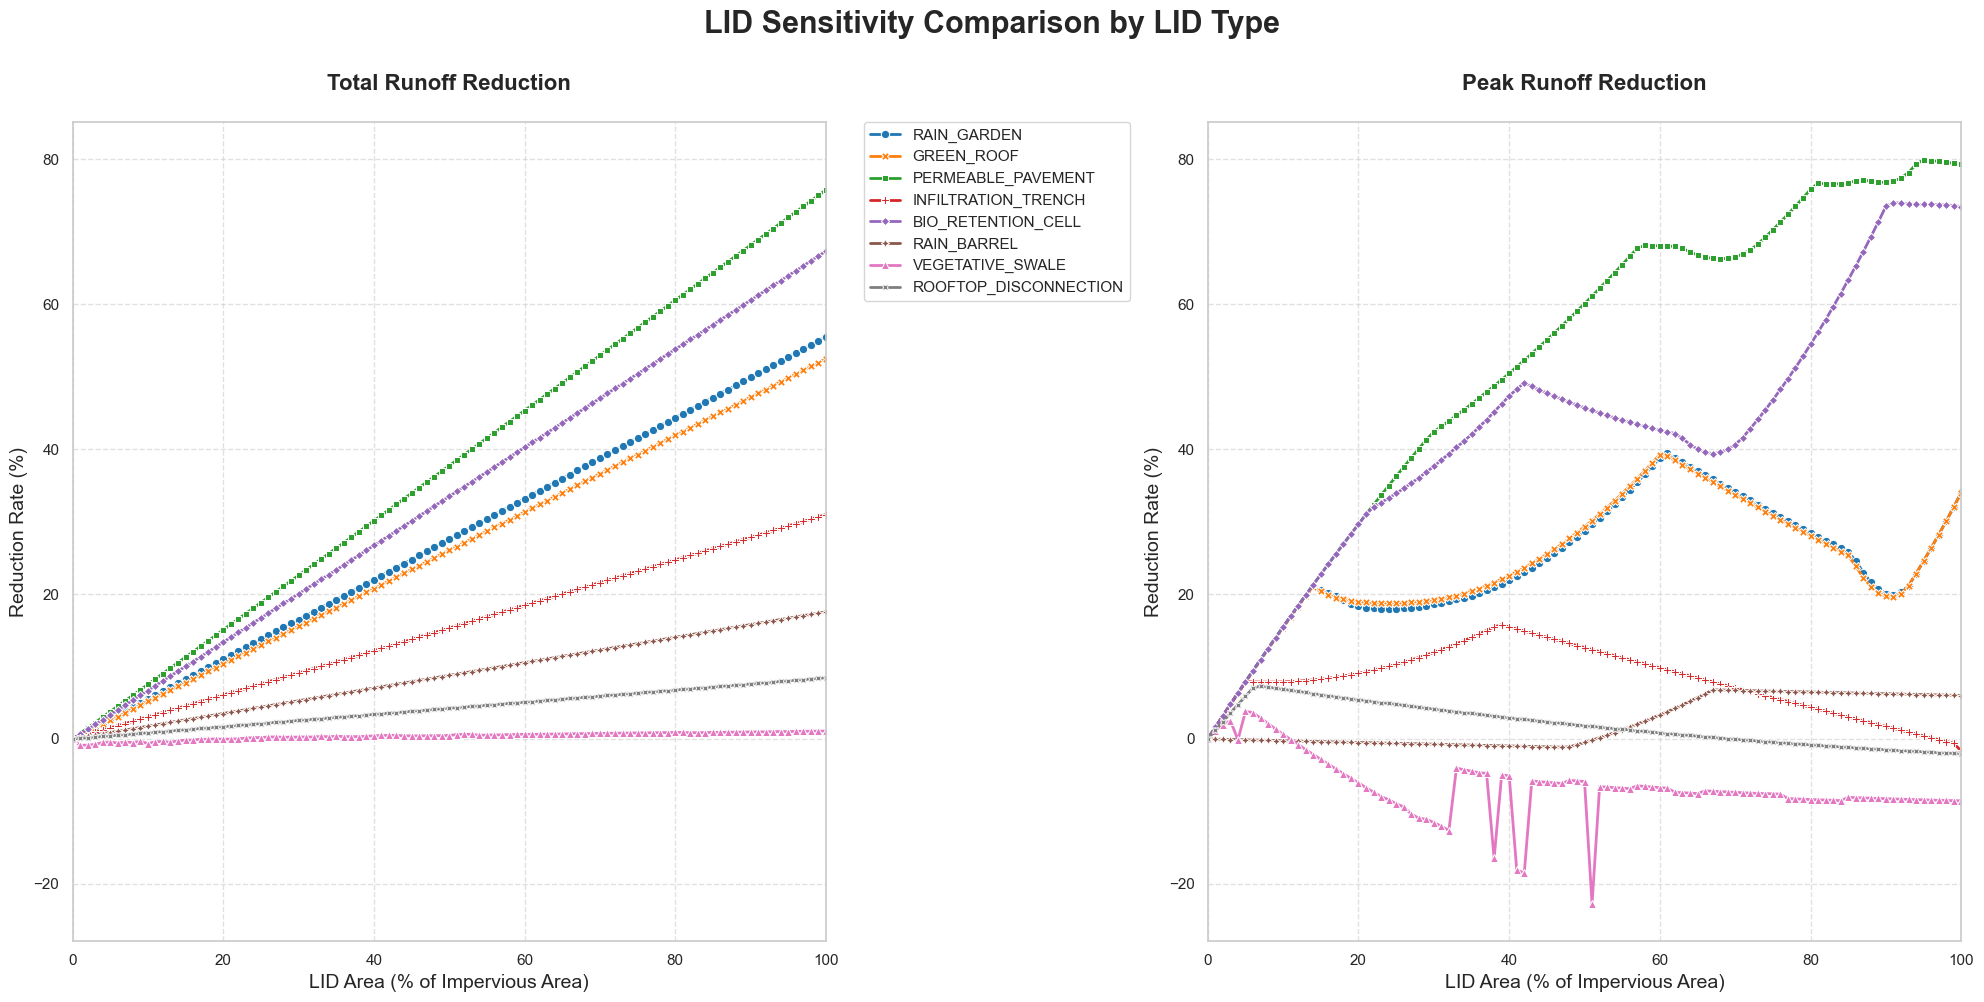

In [6]:
visualize_comparison(df_seocho2, 4)

In [7]:
csv_path="./ex1_all_lid/all_lid_sensitivity_data.csv"
df_ex1 = pd.read_csv(csv_path)
df_ex1.groupby("LID_Type")["Red_Total"].describe()

,count,mean,std,min,25%,50%,75%,max
LID_Type,,,,,,,,
BIO_RETENTION_CELL,101.0,57.444850,29.188606,0.0,33.836481,61.596184,83.250737,98.773846
GREEN_ROOF,101.0,57.444850,29.188606,0.0,33.836481,61.596184,83.250737,98.773846
INFILTRATION_TRENCH,101.0,57.444850,29.188606,0.0,33.836481,61.596184,83.250737,98.773846
PERMEABLE_PAVEMENT,101.0,57.444850,29.188606,0.0,33.836481,61.596184,83.250737,98.773846
RAIN_BARREL,101.0,57.444850,29.188606,0.0,33.836481,61.596184,83.250737,98.773846
RAIN_GARDEN,101.0,57.444850,29.188606,0.0,33.836481,61.596184,83.250737,98.773846
ROOFTOP_DISCONNECTION,101.0,57.444850,29.188606,0.0,33.836481,61.596184,83.250737,98.773846
VEGETATIVE_SWALE,101.0,6.367013,4.349425,0.0,2.401353,6.183174,10.163407,13.887078



Generating Comparative Visualization...


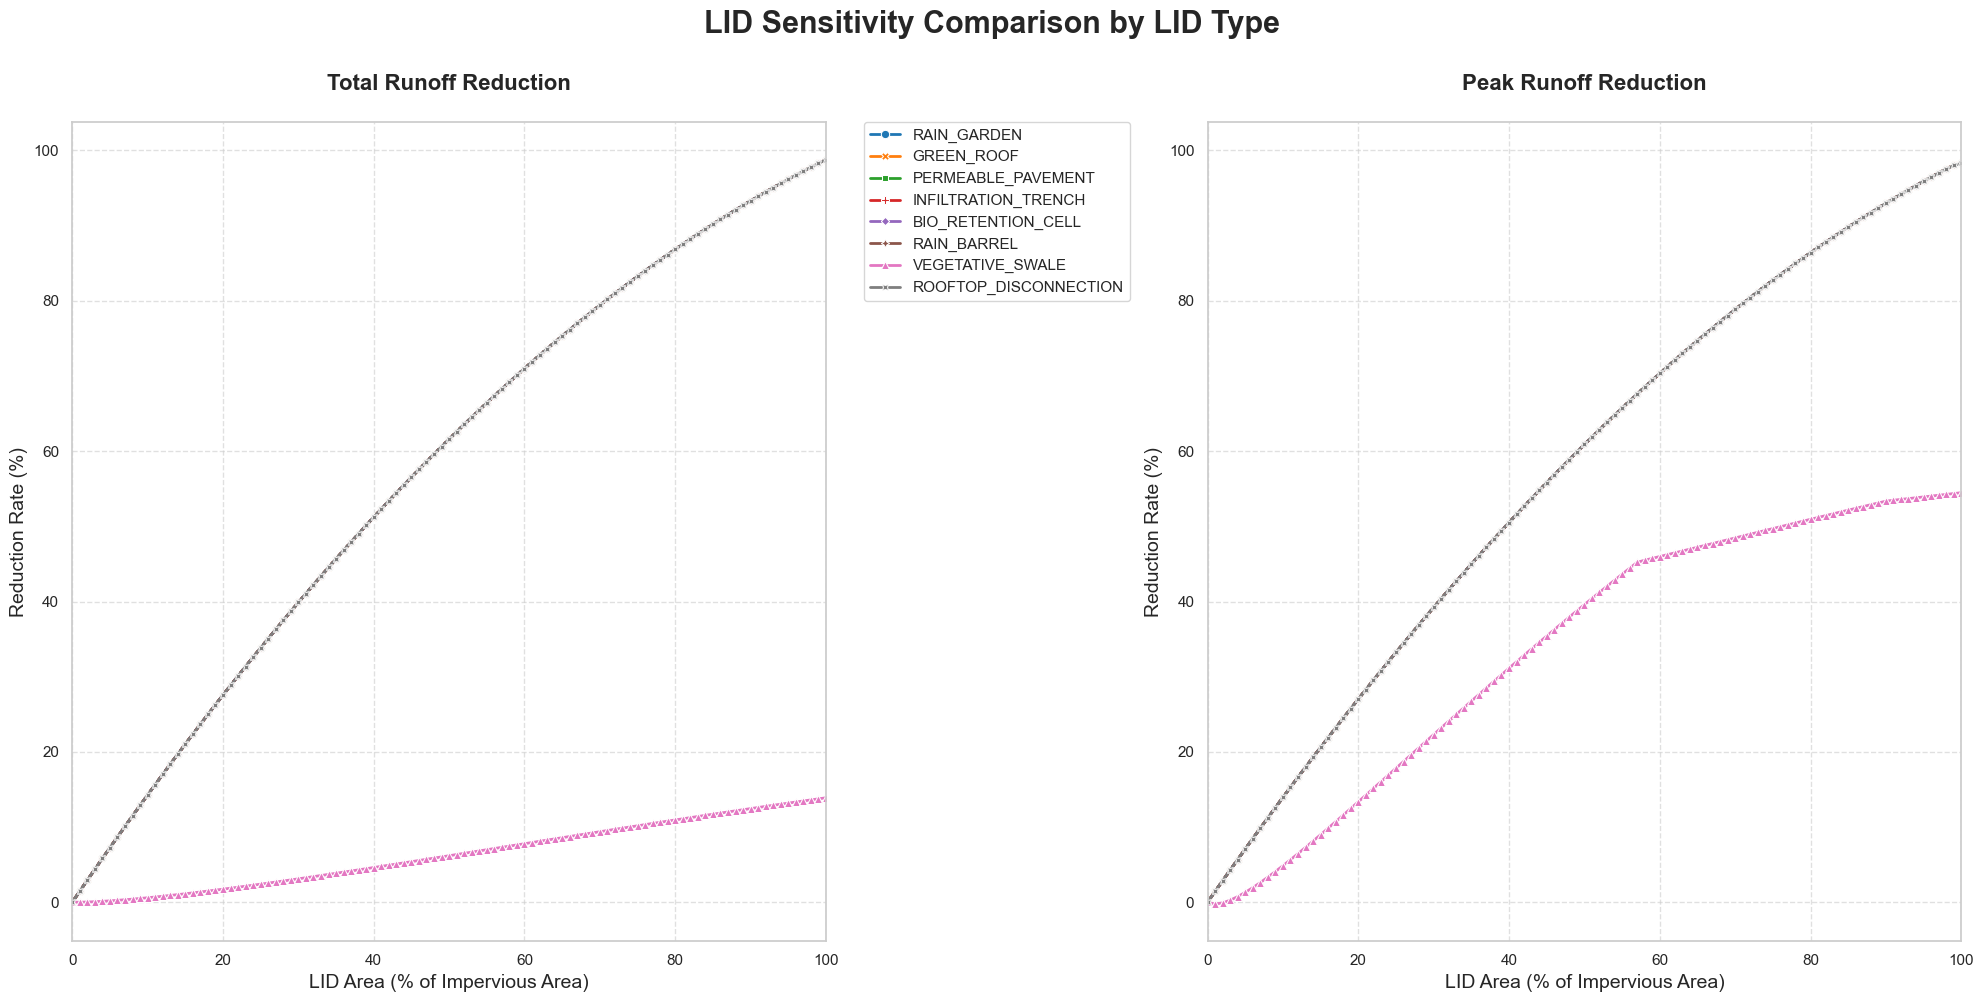

In [8]:
visualize_comparison(df_ex1, 5)

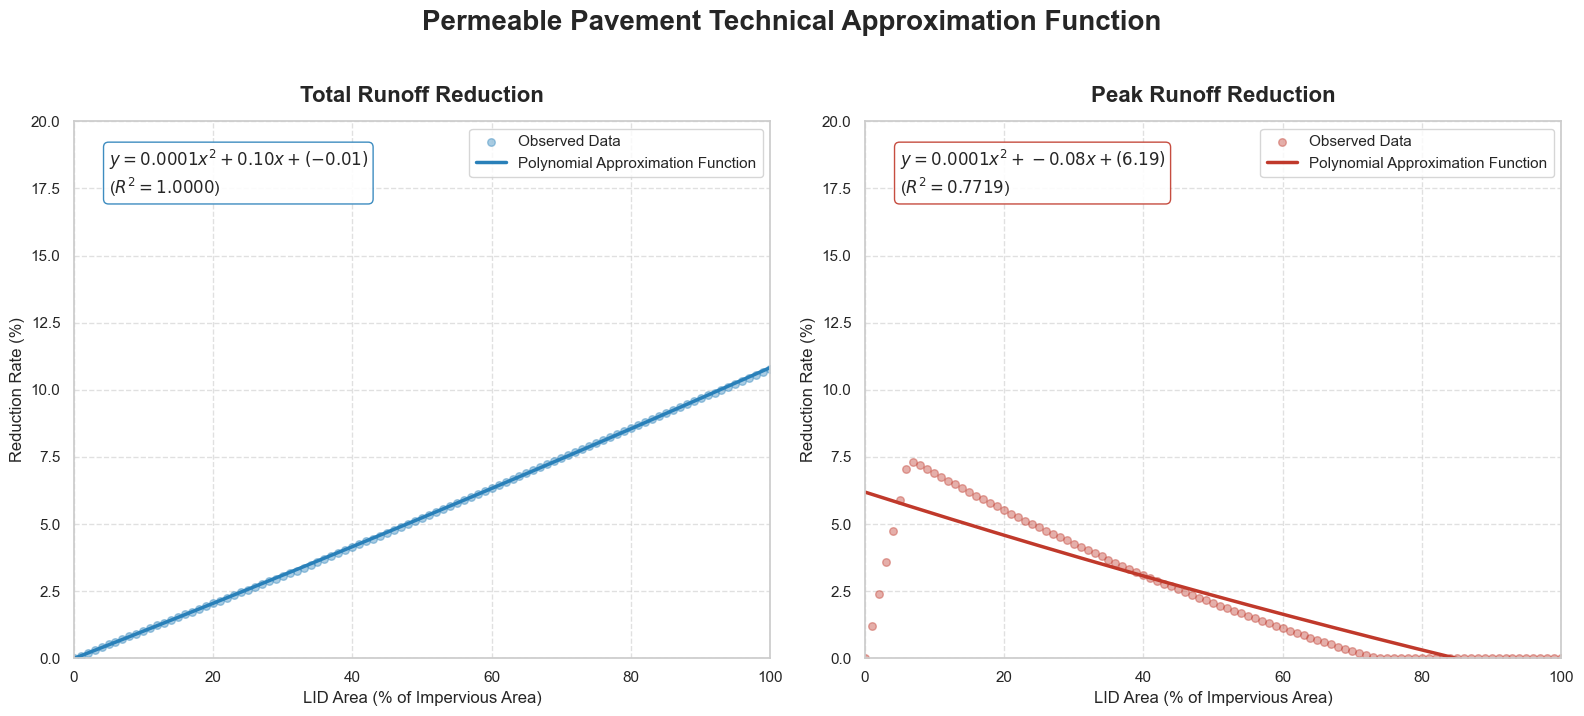

In [19]:
csv_path = "./seocho2_all_lid/PP_data.csv"
df_secho2_pp = pd.read_csv(csv_path)
visualize_results(df_secho2_pp, "Permeable Pavement")